# Koalas_Dask - Small Dataset

**Summary of this Notebook:**

This notebook presents a comprehensive performance benchmarking study comparing Koalas (based on PySpark) and Dask, two popular distributed data processing frameworks in Python. The evaluation was conducted using a small dataset, allowing a controlled and focused analysis of execution behavior without the overhead of large-scale data.

The benchmarking includes a diverse set of operations to understand how each framework performs under different scenarios:

Standard Operations: A baseline comparison covering typical data processing tasks such as arithmetic operations, joins, groupby statistics, and file reading.

Filtering: Operations were executed on filtered datasets to reflect real-world usage where data is often subsetted based on specific conditions.

Filtering with Caching: To assess the impact of in-memory optimizations, we repeated the filtered operations with caching enabled.

Each test measured execution time across both frameworks, and results were compared using both absolute timings and relative performance ratios. The goal is to identify strengths and weaknesses in each framework’s execution model and provide guidance on their suitability for different data processing tasks.

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("Samples/balanced_small.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730009 entries, 0 to 730008
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   vendor_name            730009 non-null  object        
 1   Trip_Pickup_DateTime   730009 non-null  datetime64[ns]
 2   Trip_Dropoff_DateTime  730009 non-null  object        
 3   Passenger_Count        730009 non-null  int64         
 4   Trip_Distance          730009 non-null  float64       
 5   Start_Lon              730009 non-null  float64       
 6   Start_Lat              730009 non-null  float64       
 7   End_Lon                730009 non-null  float64       
 8   End_Lat                730009 non-null  float64       
 9   Payment_Type           730009 non-null  object        
 10  Fare_Amt               730009 non-null  float64       
 11  surcharge              730009 non-null  float64       
 12  Tip_Amt                730009 non-null  floa

**Load and Clean Dataset**

The small dataset is first loaded using Pandas and its index is reset to avoid hidden columns.
Then, a cleaned version is saved as a new .parquet file to ensure consistency before benchmarking.

In [4]:
# Step 1: Load with Pandas and reset index
df = pd.read_parquet("Samples/balanced_small.parquet")
df = df.reset_index()  # Ensures no hidden index column remains

# Step 2: Save a clean version
df.to_parquet("Samples/sample_2009_2010_small_clean.parquet", index=False)

# Benchmark

**Prepare Koalas Environment with PySpark Compatibility**

To ensure compatibility between workers and driver, both are explicitly set to use the same Python version (3.7).
The JAVA_HOME path is also defined to properly run Spark-based operations in the environment.

**Set-up**

In [ ]:
# ENSURE THAT WORKERS AND DRIVER RUN THE SAME PYTHON VERSION
import os
import sys


# Set both to the same Python version
os.environ["PYSPARK_PYTHON"] = "/opt/conda/envs/cdle/bin/python3.7"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/opt/conda/envs/cdle/bin/python3.7"

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

print(sys.executable)
print(sys.version)

/opt/conda/envs/cdle/bin/python
3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:21) 
[GCC 9.4.0]


**Initialize Spark Session and Configure Runtime**

A Spark session is initialized with specific Python executables to match PySpark requirements.
Additionally, the Databricks I/O cache is disabled to measure raw execution times without caching effects.

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark session with defined Python executables
spark = SparkSession.builder \
    .appName("project") \
    .config("spark.pyspark.python", "/usr/bin/python3.7") \
    .config("spark.pyspark.driver.python", "/usr/bin/python3.7") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

# Disable caching to benchmark raw performance
spark.conf.set("spark.databricks.io.cache.enabled", "false")
print("spark.databricks.io.cache.enabled is %s" % spark.conf.get("spark.databricks.io.cache.enabled"))

spark.databricks.io.cache.enabled is false


In [8]:
print(spark.sparkContext.getConf().get("spark.pyspark.python"))
print(spark.sparkContext.getConf().get("spark.pyspark.driver.python"))

/usr/bin/python3.7
/usr/bin/python3.7


**Import Required Libraries and Verify Environment Versions**

All necessary libraries—pandas, numpy, koalas, dask, pyarrow, pyspark—are imported.
Library versions are printed to ensure consistency and reproducibility across benchmarks.

FutureWarnings are suppressed to keep the output clean and focused during benchmarking.
This avoids noise in logs, especially when using evolving libraries like Koalas and Dask.

In [ ]:
# Import all required libraries and check versions
import pandas as pd
import numpy as np
import pyspark
import pyarrow
import databricks.koalas as ks
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster
 
print('pandas version: %s' % pd.__version__)
print('numpy version: %s' % np.__version__)
print('koalas version: %s' % ks.__version__)
print("pyspark version:", pyspark.__version__)
print("pyarrow version:", pyarrow.__version__)

import dask
print('dask version: %s' % dask.__version__)


# Suppress warnings for cleaner output
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

pandas version: 1.1.5
numpy version: 1.19.5
koalas version: 1.7.0
pyspark version: 3.4.4
pyarrow version: 1.0.1
dask version: 2022.02.0


**Benchmark**

Benchmarking was performed on each operation using the custom benchmark function.
This function recorded the execution time of each task on the Koalas DataFrame and stored the results for later analysis. It enabled a systematic comparison of operation durations across different processing scenarios.


In [10]:
def benchmark(f, df, benchmarks, name, **kwargs):
    """Benchmark the given function against the given DataFrame.
    
    Parameters
    ----------
    f: function to benchmark
    df: data frame
    benchmarks: container for benchmark results
    name: task name
    
    Returns
    -------
    Duration (in seconds) of the given operation
    """
    start_time = time.time()
    ret = f(df, **kwargs)
    benchmarks['duration'].append(time.time() - start_time)
    benchmarks['task'].append(name)
    print(f"{name} took: {benchmarks['duration'][-1]} seconds")
    return benchmarks['duration'][-1]
 
def get_results(benchmarks):
    """Return a pandas DataFrame containing benchmark results."""
    return pd.DataFrame.from_dict(benchmarks)

# Dataset Information

#### Regular Dataset

The clean Parquet dataset was loaded using Koalas.

Three separate benchmark containers were initialized (koalas_benchmarks, koalas_benchmarks_filtered, and koalas_benchmarks_cache) to store execution times for the full, filtered, and cached scenarios respectively.

In [ ]:
# Load cleaned small dataset with Koalas
koalas_data = ks.read_parquet("Samples/sample_2009_2010_small_clean.parquet")

# Initialize benchmark containers for each scenario
koalas_benchmarks = {
    'duration': [],  # in seconds
    'task': [],
}

koalas_benchmarks_filtered = {
    'duration': [],  # in seconds
    'task': [],
}

koalas_benchmarks_cache = {
    'duration': [],  # in seconds
    'task': [],
}

In [ ]:
# Display the first 10 rows of the loaded Koalas DataFrame
koalas_data.head(10)

,index,vendor_name,Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Start_Lon,Start_Lat,End_Lon,End_Lat,Payment_Type,Fare_Amt,surcharge,Tip_Amt,Tolls_Amt,Total_Amt,year,month,day,hour
0,0,CMT,2009-01-01 00:45:16,2009-01-01 01:01:48,1,4.8,-73.955986,40.776054,-73.978488,40.728903,Cash,15.0,0.0,0.00,0.0,15.00,2009,1,1,0
1,1,CMT,2009-01-01 00:30:50,2009-01-01 00:34:37,1,0.4,-73.993314,40.744723,-73.985561,40.741991,Cash,4.6,0.0,0.00,0.0,4.60,2009,1,1,0
2,2,CMT,2009-01-01 00:39:49,2009-01-01 00:47:58,1,1.9,-73.969583,40.769001,-73.975622,40.787921,Cash,7.8,0.0,0.00,0.0,7.80,2009,1,1,0
3,3,CMT,2009-01-01 00:47:32,2009-01-01 00:56:22,1,1.6,-73.950814,40.779275,-73.965337,40.759277,Cash,7.8,0.0,0.00,0.0,7.80,2009,1,1,0
4,4,CMT,2009-01-01 00:26:15,2009-01-01 00:26:38,1,0.1,-73.926332,40.808143,-73.928372,40.808988,Cash,3.0,0.0,0.00,0.0,3.00,2009,1,1,0
5,5,CMT,2009-01-01 00:38:29,2009-01-01 00:59:03,3,7.8,-74.003245,40.733577,-73.963703,40.810218,Credit,21.0,0.0,5.25,0.0,26.25,2009,1,1,0
6,6,CMT,2009-01-01 00:41:06,2009-01-01 00:50:13,2,1.0,-73.990086,40.740832,-73.980446,40.746520,Cash,7.0,0.0,0.00,0.0,7.00,2009,1,1,0
7,7,DDS,2009-01-01 00:11:46,2009-01-01 00:25:06,2,1.6,-73.994876,40.755437,-73.983055,40.739024,CREDIT,8.1,0.5,2.00,0.0,10.60,2009,1,1,0
8,8,CMT,2009-01-01 00:36:12,2009-01-01 01:10:28,2,5.6,-73.953678,40.784593,-73.983188,40.729943,Cash,21.4,0.0,0.00,0.0,21.40,2009,1,1,0
9,9,CMT,2009-01-01 00:02:14,2009-01-01 00:09:26,1,1.5,-74.001634,40.730793,-73.991639,40.748866,Cash,6.6,0.0,0.00,0.0,6.60,2009,1,1,0


#### Standard Operations

A set of data processing functions was defined for benchmarking purposes.
These functions cover common operations such as aggregations, arithmetic computations, statistical summaries, groupby operations, and joins, enabling performance evaluation across a variety of tasks.


In [ ]:
# Define a set of utility functions to perform various data operations for benchmarking

def read_file_parquet(df=None):
    return ks.read_parquet("Samples/sample_2009_2010_small_clean.parquet")

def count(df=None):
    return len(df)
 
def count_index_length(df=None):
    return len(df.index)
 
def mean(df):
    return df.Fare_Amt.mean()
 
def standard_deviation(df):
    return df.Fare_Amt.std()
 
def mean_of_sum(df):
    return (df.Fare_Amt + df.Tip_Amt).mean()
 
def sum_columns(df):
    x = df.Fare_Amt + df.Tip_Amt
    x.to_pandas()
    return x
 
def mean_of_product(df):
    return (df.Fare_Amt * df.Tip_Amt).mean()
 
def product_columns(df):
    x = df.Fare_Amt * df.Tip_Amt
    x.to_pandas()
    return x
 
def value_counts(df):
    val_counts = df.Fare_Amt.value_counts()
    val_counts.to_pandas()
    return val_counts
  
def complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2 - theta_1) / 2 * np.pi / 180) ** 2
           + np.cos(theta_1 * np.pi / 180) * np.cos(theta_2 * np.pi / 180) * np.sin((phi_2 - phi_1) / 2 * np.pi / 180) ** 2)
    ret = np.multiply(np.arctan2(np.sqrt(temp), np.sqrt(1-temp)),2)
    ret.to_pandas()
    return ret
  
def mean_of_complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2 - theta_1) / 2 * np.pi / 180) ** 2
           + np.cos(theta_1 * np.pi / 180) * np.cos(theta_2 * np.pi / 180) * np.sin((phi_2 - phi_1) / 2 * np.pi / 180) ** 2)
    ret = np.multiply(np.arctan2(np.sqrt(temp), np.sqrt(1-temp)),2) 
    return ret.mean()
  
def groupby_statistics(df):
    gb = df.groupby(by='Passenger_Count').agg(
      {
        'Fare_Amt': ['mean', 'std'], 
        'Tip_Amt': ['mean', 'std']
      }
    )
    gb.to_pandas()
    return gb

# Create helper dataframe for joining
other = ks.DataFrame(groupby_statistics(koalas_data).to_pandas())
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
def join_count(df, other):
    return len(df.merge(other.spark.hint("broadcast"), left_index=True, right_index=True))
 
def join_data(df, other):
    ret = df.merge(other.spark.hint("broadcast"), left_index=True, right_index=True)
    ret.to_pandas()
    return ret

After that, each function was benchmarked using the benchmark() utility.
The tasks were applied to the Koalas DataFrame and their execution durations were stored in the koalas_benchmarks container for later analysis and visualization.

In [ ]:
# Apply each operation and record benchmark using the utility function
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks, name='read file')
benchmark(count, df=koalas_data, benchmarks=koalas_benchmarks, name='count')
benchmark(count_index_length, df=koalas_data, benchmarks=koalas_benchmarks, name='count index length')
benchmark(mean, df=koalas_data, benchmarks=koalas_benchmarks, name='mean')
benchmark(standard_deviation, df=koalas_data, benchmarks=koalas_benchmarks, name='standard deviation')
benchmark(mean_of_sum, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of columns addition')
benchmark(sum_columns, df=koalas_data, benchmarks=koalas_benchmarks, name='addition of columns')
benchmark(mean_of_product, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of columns multiplication')
benchmark(product_columns, df=koalas_data, benchmarks=koalas_benchmarks, name='multiplication of columns')
benchmark(value_counts, df=koalas_data, benchmarks=koalas_benchmarks, name='value counts')
benchmark(complicated_arithmetic_operation, df=koalas_data, benchmarks=koalas_benchmarks, name='complex arithmetic ops')
benchmark(mean_of_complicated_arithmetic_operation, df=koalas_data, benchmarks=koalas_benchmarks, name='mean of complex arithmetic ops')
benchmark(groupby_statistics, df=koalas_data, benchmarks=koalas_benchmarks, name='groupby statistics')
benchmark(join_count, koalas_data, benchmarks=koalas_benchmarks, name='join count', other=other)
benchmark(join_data, koalas_data, benchmarks=koalas_benchmarks, name='join', other=other)

read file took: 0.20673680305480957 seconds
count took: 0.16984295845031738 seconds
count index length took: 0.1397871971130371 seconds
mean took: 0.16881561279296875 seconds
standard deviation took: 0.17994999885559082 seconds
mean of columns addition took: 0.1900949478149414 seconds


addition of columns took: 3.651552677154541 seconds
mean of columns multiplication took: 0.2300267219543457 seconds
multiplication of columns took: 2.8796286582946777 seconds
value counts took: 0.6893925666809082 seconds


complex arithmetic ops took: 4.610354423522949 seconds
mean of complex arithmetic ops took: 1.5290274620056152 seconds
groupby statistics took: 0.2883632183074951 seconds
join count took: 1.308147668838501 seconds


join took: 2.0273261070251465 seconds


2.0273261070251465

**Save results**

The results were retrieved from the benchmark dictionary and duplicates were removed.
The results were indexed by task name and stored in a DataFrame for exporting.

The DataFrame was saved as a Parquet file for later access.
This allows for efficient, structured storage of benchmarking results.

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
koalas_res_temp = get_results(koalas_benchmarks).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(koalas_res_temp)

# Define the file path for saving
filename = 'Results/koalas_local'

# Save the result DataFrame as a Parquet file
koalas_res_temp.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}.')

                                duration
task                                    
read file                       0.206737
count                           0.169843
count index length              0.139787
mean                            0.168816
standard deviation              0.179950
mean of columns addition        0.190095
addition of columns             3.651553
mean of columns multiplication  0.230027
multiplication of columns       2.879629
value counts                    0.689393
complex arithmetic ops          4.610354
mean of complex arithmetic ops  1.529027
groupby statistics              0.288363
join count                      1.308148
join                            2.027326
O arquivo Parquet foi salvo em Results/koalas_local.


## Operations with filtering 

This section filters the dataset to include only rows where the Tip_Amt is between 1 and 5.

All benchmark functions are then re-executed on this filtered subset. The goal is to benchmark Koalas' performance on a smaller, constrained dataset and observe how execution time changes.

This provides insights into how Koalas handles filtered subsets compared to the full dataset.

In [16]:
expr_filter = (koalas_data.Tip_Amt >= 1) & (koalas_data.Tip_Amt <= 5)
 
def filter_data(df):
    return df[expr_filter]

koalas_filtered = filter_data(koalas_data)

In [17]:
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks_filtered, name='read file')
benchmark(count, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='count')
benchmark(count_index_length, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='count index length')
benchmark(mean, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='mean')
benchmark(standard_deviation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='standard deviation')
benchmark(mean_of_sum, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='mean of columns addition')
benchmark(sum_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='addition of columns')
benchmark(mean_of_product, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='mean of columns multiplication')
benchmark(product_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='complex arithmetic ops')
benchmark(value_counts, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name ='value counts')
benchmark(groupby_statistics, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='groupby statistics')
 
other = ks.DataFrame(groupby_statistics(koalas_filtered).to_pandas())
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
benchmark(join_data, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='join', other=other)
benchmark(join_count, koalas_filtered, benchmarks=koalas_benchmarks_filtered, name='join count', other=other)

read file took: 0.14222431182861328 seconds
count took: 0.19246935844421387 seconds
count index length took: 0.12078475952148438 seconds
mean took: 0.20544958114624023 seconds
standard deviation took: 0.24187016487121582 seconds
mean of columns addition took: 0.2510201930999756 seconds
addition of columns took: 1.2459886074066162 seconds
mean of columns multiplication took: 0.20132756233215332 seconds
multiplication of columns took: 1.190103530883789 seconds
mean of complex arithmetic ops took: 1.3689594268798828 seconds
complex arithmetic ops took: 2.4781875610351562 seconds
value counts took: 0.4300556182861328 seconds
groupby statistics took: 0.3596339225769043 seconds


join took: 1.9248216152191162 seconds
join count took: 0.7553651332855225 seconds


0.7553651332855225

**Save Results**

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
koalas_res_filtered = get_results(koalas_benchmarks_filtered).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(koalas_res_filtered)

# Define the file path for saving
filename_filter = 'Results/koalas_local_filtered'

# Save the result DataFrame as a Parquet file
koalas_res_filtered.to_parquet(filename_filter)

print(f'O arquivo Parquet foi salvo em {filename_filter}.')

                                duration
task                                    
read file                       0.142224
count                           0.192469
count index length              0.120785
mean                            0.205450
standard deviation              0.241870
mean of columns addition        0.251020
addition of columns             1.245989
mean of columns multiplication  0.201328
multiplication of columns       1.190104
mean of complex arithmetic ops  1.368959
complex arithmetic ops          2.478188
value counts                    0.430056
groupby statistics              0.359634
join                            1.924822
join count                      0.755365
O arquivo Parquet foi salvo em Results/koalas_local_filtered.


## Operations with filtering and cache

This section applies caching to the filtered Koalas DataFrame using Spark’s cache mechanism.

Caching stores the filtered data in memory to speed up repeated operations on the same subset.

Benchmarks are re-run on the cached data to measure performance improvements gained by memory persistence.

The results are collected, duplicates removed, and then saved to a Parquet file for later analysis.

In [ ]:
# Add caching to the filtered DataFrame to persist data in memory
koalas_filtered = koalas_filtered.spark.cache()
print(f'Enforce caching: {len(koalas_filtered)} rows of filtered data')

Enforce caching: 189696 rows of filtered data


In [ ]:
# Re-run all benchmark tests on the cached filtered data
benchmark(read_file_parquet, df=None, benchmarks=koalas_benchmarks_cache, name='read file')
benchmark(count, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='count')
benchmark(count_index_length, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='count index length')
benchmark(mean, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean')
benchmark(standard_deviation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='standard deviation')
benchmark(mean_of_sum, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of columns addition')
benchmark(sum_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='addition of columns')
benchmark(mean_of_product, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of columns multiplication')
benchmark(product_columns, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='multiplication of columns')
benchmark(value_counts, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='value counts')
benchmark(complicated_arithmetic_operation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='complex arithmetic ops')
benchmark(mean_of_complicated_arithmetic_operation, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='mean of complex arithmetic ops')
benchmark(groupby_statistics, df=koalas_filtered, benchmarks=koalas_benchmarks_cache, name='groupby statistics')
benchmark(join_count, koalas_filtered, benchmarks=koalas_benchmarks_cache, name='join count', other=other)
benchmark(join_data, koalas_filtered, benchmarks=koalas_benchmarks_cache, name='join', other=other)

read file took: 0.14325714111328125 seconds
count took: 0.0384519100189209 seconds
count index length took: 0.04614448547363281 seconds
mean took: 0.10049104690551758 seconds
standard deviation took: 0.08975982666015625 seconds
mean of columns addition took: 0.1020197868347168 seconds
addition of columns took: 0.9000613689422607 seconds
mean of columns multiplication took: 0.09752941131591797 seconds
multiplication of columns took: 0.7375409603118896 seconds
value counts took: 0.14145827293395996 seconds
complex arithmetic ops took: 1.916884183883667 seconds
mean of complex arithmetic ops took: 1.2144825458526611 seconds
groupby statistics took: 0.30156803131103516 seconds
join count took: 0.36897897720336914 seconds
join took: 0.5780820846557617 seconds


0.5780820846557617

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
koalas_res_cache = get_results(koalas_benchmarks_cache).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(koalas_res_cache)

# Define output filename for cached results
filename_cache = 'Results/koalas_local_cache'

# Save results DataFrame as a Parquet file
koalas_res_cache.to_parquet(filename_cache)

print(f'O arquivo Parquet foi salvo em {filename_cache}.')

                                duration
task                                    
read file                       0.143257
count                           0.038452
count index length              0.046144
mean                            0.100491
standard deviation              0.089760
mean of columns addition        0.102020
addition of columns             0.900061
mean of columns multiplication  0.097529
multiplication of columns       0.737541
value counts                    0.141458
complex arithmetic ops          1.916884
mean of complex arithmetic ops  1.214483
groupby statistics              0.301568
join count                      0.368979
join                            0.578082
O arquivo Parquet foi salvo em Results/koalas_local_cache.


# Dask

This section reads the entire dataset from a Parquet file into a pandas DataFrame and then converts it into a Dask DataFrame with one partition.

A set of benchmark functions is defined to perform various operations on the Dask DataFrame. Each function uses Dask’s lazy evaluation and explicitly calls .compute() to trigger the actual computation.

After defining these functions, the code initializes a Dask client for parallel computation and runs all benchmark functions on the full Dask dataset, recording their durations for performance comparison.

In [ ]:
import pandas as pd
import dask.dataframe as dd

# Read the entire Parquet file using pandas
df = pd.read_parquet("Samples/sample_2009_2010_small_clean.parquet", engine="pyarrow")

# Convert the pandas DataFrame to a Dask DataFrame
dask_data = dd.from_pandas(df, npartitions=1)

In [ ]:
# Dictionaries to store benchmark results for different stages
dask_benchmarks = {
    'duration': [],  # in seconds
    'task': [],
}

dask_benchmarks_filtered = {
    'duration': [],  # in seconds
    'task': [],
}
dask_benchmarks_cache = {
    'duration': [],  # in seconds
    'task': [],
}

**Standard Operations**

In [25]:
def read_file_parquet(df=None):
    return dd.read_parquet("Samples/sample_2009_2010_small_clean.parquet")
  
def count(df=None):
    return len(df)
 
def count_index_length(df=None):
    return len(df.index)
 
def mean(df):
    return df.Fare_Amt.mean().compute()
 
def standard_deviation(df):
    return df.Fare_Amt.std().compute()
 
def mean_of_sum(df):
    return (df.Fare_Amt + df.Tip_Amt).mean().compute()
 
def sum_columns(df):
    return (df.Fare_Amt + df.Tip_Amt).compute()
 
def mean_of_product(df):
    return (df.Fare_Amt * df.Tip_Amt).mean().compute()
 
def product_columns(df):
    return (df.Fare_Amt * df.Tip_Amt).compute()
  
def value_counts(df):
    return df.Fare_Amt.value_counts().compute()
  
def mean_of_complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2-theta_1)/2*np.pi/180)**2
           + np.cos(theta_1*np.pi/180)*np.cos(theta_2*np.pi/180) * np.sin((phi_2-phi_1)/2*np.pi/180)**2)
    ret = 2 * np.arctan2(np.sqrt(temp), np.sqrt(1-temp))
    return ret.mean().compute()
  
def complicated_arithmetic_operation(df):
    theta_1 = df.Start_Lon
    phi_1 = df.Start_Lat
    theta_2 = df.End_Lon
    phi_2 = df.End_Lat
    temp = (np.sin((theta_2-theta_1)/2*np.pi/180)**2
           + np.cos(theta_1*np.pi/180)*np.cos(theta_2*np.pi/180) * np.sin((phi_2-phi_1)/2*np.pi/180)**2)
    ret = 2 * np.arctan2(np.sqrt(temp), np.sqrt(1-temp))
    return ret.compute()
  
def groupby_statistics(df):
    return df.groupby(by='Passenger_Count').agg(
      {
        'Fare_Amt': ['mean', 'std'], 
        'Tip_Amt': ['mean', 'std']
      }
    ).compute()
  
other = groupby_statistics(dask_data)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
def join_count(df, other):
    return len(dd.merge(df, other, left_index=True, right_index=True))
 
def join_data(df, other):
    return dd.merge(df, other, left_index=True, right_index=True).compute()

In [ ]:
# Initialize Dask distributed client for parallel computation
client = Client()

# Run benchmarks on the full Dask dataset
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks, name='read file')
benchmark(count, df=dask_data, benchmarks=dask_benchmarks, name='count')
benchmark(count_index_length, df=dask_data, benchmarks=dask_benchmarks, name='count index length')
benchmark(mean, df=dask_data, benchmarks=dask_benchmarks, name='mean')
benchmark(standard_deviation, df=dask_data, benchmarks=dask_benchmarks, name='standard deviation')
benchmark(mean_of_sum, df=dask_data, benchmarks=dask_benchmarks, name='mean of columns addition')
benchmark(sum_columns, df=dask_data, benchmarks=dask_benchmarks, name='addition of columns')
benchmark(mean_of_product, df=dask_data, benchmarks=dask_benchmarks, name='mean of columns multiplication')
benchmark(product_columns, df=dask_data, benchmarks=dask_benchmarks, name='multiplication of columns')
benchmark(value_counts, df=dask_data, benchmarks=dask_benchmarks, name='value counts')
benchmark(mean_of_complicated_arithmetic_operation, df=dask_data, benchmarks=dask_benchmarks, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, df=dask_data, benchmarks=dask_benchmarks, name='complex arithmetic ops')
benchmark(groupby_statistics, df=dask_data, benchmarks=dask_benchmarks, name='groupby statistics')
benchmark(join_count, dask_data, benchmarks=dask_benchmarks, name='join count', other=other)
benchmark(join_data, dask_data, benchmarks=dask_benchmarks, name='join', other=other)

read file took: 0.012751579284667969 seconds
count took: 0.9922590255737305 seconds
count index length took: 0.853722333908081 seconds
mean took: 0.9080471992492676 seconds
standard deviation took: 0.8901219367980957 seconds
mean of columns addition took: 0.6792805194854736 seconds
addition of columns took: 0.6704952716827393 seconds
mean of columns multiplication took: 0.676224946975708 seconds
multiplication of columns took: 0.6581807136535645 seconds
value counts took: 0.6864433288574219 seconds
mean of complex arithmetic ops took: 0.7439217567443848 seconds
complex arithmetic ops took: 0.7289199829101562 seconds
groupby statistics took: 0.6811039447784424 seconds
join count took: 0.8191709518432617 seconds
join took: 0.7738039493560791 seconds


0.7738039493560791

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
dask_res_temp = get_results(dask_benchmarks).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(dask_res_temp)

# Define output filename for cached results
filename = 'Results/dask_local'

# Save results DataFrame as a Parquet file
dask_res_temp.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}.')

client.restart()

                                duration
task                                    
read file                       0.012752
count                           0.992259
count index length              0.853722
mean                            0.908047
standard deviation              0.890122
mean of columns addition        0.679281
addition of columns             0.670495
mean of columns multiplication  0.676225
multiplication of columns       0.658181
value counts                    0.686443
mean of complex arithmetic ops  0.743922
complex arithmetic ops          0.728920
groupby statistics              0.681104
join count                      0.819171
join                            0.773804
O arquivo Parquet foi salvo em Results/dask_local.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42881,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:35625,Total threads: 2
Dashboard: http://127.0.0.1:40221/status,Memory: 7.83 GiB
Nanny: tcp://127.0.0.1:34695,


### Operations with filtering

This section defines a filter expression on the Tip_Amt column to select rows where the tip amount is between 1 and 5 (inclusive).

A function filter_data applies this filter on a Dask DataFrame, returning a filtered Dask DataFrame.

Benchmarks are then performed on this filtered dataset, running the same suite of operations as before (count, mean, std, arithmetic operations, groupby stats, joins).

The goal is to compare the performance of these operations on the filtered subset versus the full dataset.

The Dask client is re-initialized to ensure a clean execution environment.

In [28]:
expr_filter = (dask_data.Tip_Amt >= 1) & (dask_data.Tip_Amt <= 5)
 
def filter_data(df):
    return df[expr_filter]
  
dask_filtered = filter_data(dask_data)

In [ ]:
# Initialize Dask distributed client again for parallel computation
client = Client()

# Run benchmarks on the filtered Dask dataset
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks_filtered, name='read file')
benchmark(count, dask_filtered, benchmarks=dask_benchmarks_filtered, name='count')
benchmark(count_index_length, dask_filtered, benchmarks=dask_benchmarks_filtered, name='count index length')
benchmark(mean, dask_filtered, benchmarks=dask_benchmarks_filtered, name='mean')
benchmark(standard_deviation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='standard deviation')
benchmark(mean_of_sum, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='mean of columns addition')
benchmark(sum_columns, df=dask_filtered, benchmarks=dask_benchmarks_filtered, name='addition of columns')
benchmark(mean_of_product, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='mean of columns multiplication')
benchmark(product_columns, df=dask_filtered, benchmarks=dask_benchmarks_filtered, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_filtered, name='complex arithmetic ops')
benchmark(value_counts, dask_filtered, benchmarks=dask_benchmarks_filtered, name ='value counts')
benchmark(groupby_statistics, dask_filtered, benchmarks=dask_benchmarks_filtered, name='groupby statistics')
 
other = groupby_statistics(dask_filtered)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
benchmark(join_count, dask_filtered, benchmarks=dask_benchmarks_filtered, name='join count', other=other)
benchmark(join_data, dask_filtered, benchmarks=dask_benchmarks_filtered, name='join', other=other)

/opt/conda/envs/cdle/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46483 instead
  f"Port {expected} is already in use.\n"


read file took: 0.013402223587036133 seconds
count took: 0.9792239665985107 seconds
count index length took: 0.8408792018890381 seconds
mean took: 0.9308350086212158 seconds
standard deviation took: 0.9005541801452637 seconds
mean of columns addition took: 0.724663257598877 seconds
addition of columns took: 0.6948983669281006 seconds
mean of columns multiplication took: 0.7197709083557129 seconds
multiplication of columns took: 0.6701009273529053 seconds
mean of complex arithmetic ops took: 0.7829103469848633 seconds
complex arithmetic ops took: 0.7354023456573486 seconds
value counts took: 0.6973583698272705 seconds
groupby statistics took: 0.7181057929992676 seconds
join count took: 0.7449307441711426 seconds
join took: 0.7724244594573975 seconds


0.7724244594573975

**Save results**

In [ ]:
# Obtain results, remove duplicate tasks, and set task as index
dask_res_filtered = get_results(dask_benchmarks_filtered).drop_duplicates(subset='task').set_index('task')

# Print the benchmark results
print(dask_res_filtered)

# Define output filename for cached results
filename_filter = 'Results/dask_local_filtered'

# Save results DataFrame as a Parquet file
dask_res_filtered.to_parquet(filename_filter)

print(f'O arquivo Parquet foi salvo em {filename_filter}.')

client.restart()

                                duration
task                                    
read file                       0.013402
count                           0.979224
count index length              0.840879
mean                            0.930835
standard deviation              0.900554
mean of columns addition        0.724663
addition of columns             0.694898
mean of columns multiplication  0.719771
multiplication of columns       0.670101
mean of complex arithmetic ops  0.782910
complex arithmetic ops          0.735402
value counts                    0.697358
groupby statistics              0.718106
join count                      0.744931
join                            0.772424
O arquivo Parquet foi salvo em Results/dask_local_filtered.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:46483/status,
Dashboard: http://127.0.0.1:46483/status,Workers: 4
Total threads: 8,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36285,Workers: 4
Dashboard: http://127.0.0.1:46483/status,Total threads: 8
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:44551,Total threads: 2
Dashboard: http://127.0.0.1:46279/status,Memory: 7.83 GiB
Nanny: tcp://127.0.0.1:38243,


## Operations with filtering and cache

This section persists the filtered Dask DataFrame in cluster memory to speed up subsequent operations. The code waits until all data is fully cached before running benchmarks to measure performance gains. Aggregated statistics are computed and used for join benchmarks on the cached data.

In [ ]:
client = Client()

# Persist the filtered Dask DataFrame in cluster memory to speed up future operations
dask_filtered = client.persist(dask_filtered)
 
from distributed import wait
print('Waiting until all futures are finished')
# Wait until all computations related to the persisted data are complete
wait(dask_filtered)
print('All futures are finished')

/opt/conda/envs/cdle/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33663 instead
  f"Port {expected} is already in use.\n"


Waiting until all futures are finished
All futures are finished


In [32]:
benchmark(read_file_parquet, df=None, benchmarks=dask_benchmarks_cache, name='read file')
benchmark(count, dask_filtered, benchmarks=dask_benchmarks_cache, name='count')
benchmark(count_index_length, dask_filtered, benchmarks=dask_benchmarks_cache, name='count index length')
benchmark(mean, dask_filtered, benchmarks=dask_benchmarks_cache, name='mean')
benchmark(standard_deviation, dask_filtered, benchmarks=dask_benchmarks_cache, name='standard deviation')
benchmark(mean_of_sum, dask_filtered, benchmarks=dask_benchmarks_cache, name ='mean of columns addition')
benchmark(sum_columns, df=dask_filtered, benchmarks=dask_benchmarks_cache, name='addition of columns')
benchmark(mean_of_product, dask_filtered, benchmarks=dask_benchmarks_cache, name ='mean of columns multiplication')
benchmark(product_columns, df=dask_filtered, benchmarks=dask_benchmarks_cache, name='multiplication of columns')
benchmark(mean_of_complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_cache, name='mean of complex arithmetic ops')
benchmark(complicated_arithmetic_operation, dask_filtered, benchmarks=dask_benchmarks_cache, name='complex arithmetic ops')
benchmark(value_counts, dask_filtered, benchmarks=dask_benchmarks_cache, name ='value counts')
benchmark(groupby_statistics, dask_filtered, benchmarks=dask_benchmarks_cache, name='groupby statistics')
 
other = groupby_statistics(dask_filtered)
other.columns = pd.Index([e[0]+'_' + e[1] for e in other.columns.tolist()])
 
benchmark(join_count, dask_filtered, benchmarks=dask_benchmarks_cache, name='join count', other=other)
benchmark(join_data, dask_filtered, benchmarks=dask_benchmarks_cache, name='join', other=other)

read file took: 0.013084888458251953 seconds
count took: 0.21994853019714355 seconds
count index length took: 0.02242898941040039 seconds
mean took: 0.04245591163635254 seconds
standard deviation took: 0.04141402244567871 seconds
mean of columns addition took: 0.03294110298156738 seconds
addition of columns took: 0.023918628692626953 seconds
mean of columns multiplication took: 0.03526902198791504 seconds
multiplication of columns took: 0.016405820846557617 seconds
mean of complex arithmetic ops took: 0.0800013542175293 seconds
complex arithmetic ops took: 0.05945324897766113 seconds
value counts took: 0.02516627311706543 seconds
groupby statistics took: 0.05983614921569824 seconds
join count took: 0.27060604095458984 seconds
join took: 0.26431751251220703 seconds


0.26431751251220703

**Save Results**

In [ ]:
# Retrieve benchmark results and remove duplicate task entries
dask_res_cache = get_results(dask_benchmarks_cache).drop_duplicates(subset='task').set_index('task')

# Print the result DataFrame
print(dask_res_cache)

# Define the file path for saving
filename_cache = 'Results/dask_local_cache'

# Save the result DataFrame as a Parquet file
dask_res_cache.to_parquet(filename_cache)

print(f'O arquivo Parquet foi salvo em {filename_cache}.')

                                duration
task                                    
read file                       0.013085
count                           0.219949
count index length              0.022429
mean                            0.042456
standard deviation              0.041414
mean of columns addition        0.032941
addition of columns             0.023919
mean of columns multiplication  0.035269
multiplication of columns       0.016406
mean of complex arithmetic ops  0.080001
complex arithmetic ops          0.059453
value counts                    0.025166
groupby statistics              0.059836
join count                      0.270606
join                            0.264318
O arquivo Parquet foi salvo em Results/dask_local_cache.


## Results

We now proceed to the step of loading, concatenating, and saving the benchmark results for both Koalas and Dask. This process is repeated for the standard, filtered, and cached datasets to enable easy comparison and visualization.

In [34]:
import pandas as pd

res_koalas_local = pd.read_parquet("Results/koalas_local")
res_dask_local =  pd.read_parquet("Results/dask_local")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local['duration'], res_dask_local['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.206737  0.012752
count                           0.169843  0.992259
count index length              0.139787  0.853722
mean                            0.168816  0.908047
standard deviation              0.179950  0.890122
mean of columns addition        0.190095  0.679281
addition of columns             3.651553  0.670495
mean of columns multiplication  0.230027  0.676225
multiplication of columns       2.879629  0.658181
value counts                    0.689393  0.686443
complex arithmetic ops          4.610354  0.728920
mean of complex arithmetic ops  1.529027  0.743922
groupby statistics              0.288363  0.681104
join count                      1.308148  0.819171
join                            2.027326  0.773804


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results/results_local_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results/results_local_new


## Results for operations with filtering

In [37]:
res_koalas_local_fil = pd.read_parquet("Results/koalas_local_filtered")
res_dask_local_fil =  pd.read_parquet("Results/dask_local_filtered")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local_fil['duration'], res_dask_local_fil['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.142224  0.013402
count                           0.192469  0.979224
count index length              0.120785  0.840879
mean                            0.205450  0.930835
standard deviation              0.241870  0.900554
mean of columns addition        0.251020  0.724663
addition of columns             1.245989  0.694898
mean of columns multiplication  0.201328  0.719771
multiplication of columns       1.190104  0.670101
mean of complex arithmetic ops  1.368959  0.782910
complex arithmetic ops          2.478188  0.735402
value counts                    0.430056  0.697358
groupby statistics              0.359634  0.718106
join                            1.924822  0.772424
join count                      0.755365  0.744931


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results/results_local_filtered_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results/results_local_filtered_new


## Results for operations with filtering and cache

In [40]:
res_koalas_local_cache = pd.read_parquet("Results/koalas_local_cache")
res_dask_local_cache =  pd.read_parquet("Results/dask_local_cache")

In [ ]:
# Concatenate the results into a single DataFrame
df = pd.concat([res_koalas_local_cache['duration'], res_dask_local_cache['duration']], axis=1, keys=['koalas', 'dask'])

# Display the resulting DataFrame
print(df)

                                  koalas      dask
read file                       0.143257  0.013085
count                           0.038452  0.219949
count index length              0.046144  0.022429
mean                            0.100491  0.042456
standard deviation              0.089760  0.041414
mean of columns addition        0.102020  0.032941
addition of columns             0.900061  0.023919
mean of columns multiplication  0.097529  0.035269
multiplication of columns       0.737541  0.016406
value counts                    0.141458  0.025166
complex arithmetic ops          1.916884  0.059453
mean of complex arithmetic ops  1.214483  0.080001
groupby statistics              0.301568  0.059836
join count                      0.368979  0.270606
join                            0.578082  0.264318


In [ ]:
# Define the output file path for saving the combined results
filename = 'Results/results_local_cache_new'

# Save the concatenated DataFrame in Parquet format
df.to_parquet(filename)

print(f'O arquivo Parquet foi salvo em {filename}')

O arquivo Parquet foi salvo em Results/results_local_cache_new


# Comparison

We now move on to comparing the benchmark results by calculating the average durations for each operation across multiple runs. This includes processing the standard, filtered, and cached scenarios to obtain fair and consistent performance metrics.

In [ ]:
# This section loads multiple benchmark result files from the specified directory,
# computes a fair average runtime for each operation by excluding outliers (first run and best run),
# renames the operations for clarity, and organizes the results into separate DataFrames
# for standard, filtered, and cached benchmark scenarios.
# Finally, it displays the summarized average durations for Koalas (PySpark) and Dask for easy comparison.

In [43]:
import os
import pandas as pd
from scipy import stats
from datetime import datetime

def fair_avg(durations):
    """Get an average duration among multiple durations fairly by removing the first run and the best run first."""
    if len(durations) <= 2:  # Verifica se há pelo menos 3 durações
        return sum(durations) / len(durations) if durations else 0
    durations = durations[1:]
    durations.remove(min(durations))
    return sum(durations) / len(durations)

def rename_index(df):
    """Rename operations in the average result dataframe for clarity."""
    df.index = map(
        lambda s: s.replace("filtered ", "")
                  .replace("of columns", "of series")
                  .replace("addition of series", "series addition")
                  .replace("multiplication of series", "series multiplication")
                  .replace("arithmetic ops", "arithmetic")
                  .replace("count index length", "count index"),
        df.index)
    return df

def avg_result_df(directory, file_name_prefix):
    """Get result files with the given prefix from the given directory and then construct the average result dataframe."""
    dfs = []
    file_infos = os.listdir(directory)
    for file_info in file_infos:
        if file_info.startswith(file_name_prefix):
            dfs.append(pd.read_parquet(os.path.join(directory, file_info)))
    
    if not dfs:
        raise ValueError(f"No files found with prefix {file_name_prefix} in directory {directory}")
    
    print(f'{file_name_prefix} has {len(dfs)} runs')
    
    avg_df = dfs[0].copy()
    for op in dfs[0].index:
        for lib in ['koalas', 'dask']:
            durations = []
            for df in dfs:
                durations.append(df.loc[op][lib])
            avg_df.loc[op][lib] = fair_avg(durations)
            
    return rename_index(avg_df)

def annotate(ax):
    """Annotate the height of each bar in the plot."""
    for p in ax.patches:
        ax.annotate("%.2fs" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

def annotate_x_times_faster(ax, x_times_list):
    """Annotate Koalas is how many times faster per operation in the plot."""
    num_ops = len(x_times_list)
    for i, p in enumerate(ax.patches):
        if i < num_ops:  # The first half of ax.patches of Koalas; we only annotate Koalas patches
            ax.annotate("%.1fx" % x_times_list[i], (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(4, 10), textcoords='offset points', fontsize=8, weight='bold', color="#585858")

In [ ]:
# Define the directory path and file prefixes for result files
directory_path = 'Results'
standard_file_prefix = 'results_local_new'
filtered_file_prefix = 'results_local_filtered_new'
cache_file_prefix = 'results_local_cache_new'

# Load results and compute fair average durations
standard_res_df = avg_result_df(directory_path, standard_file_prefix)
filtered_res_df = avg_result_df(directory_path, filtered_file_prefix)
cache_res_df = avg_result_df(directory_path, cache_file_prefix)

# Rename the columns 
standard_res_df.columns = ['Koalas (PySpark)', 'Dask']
filtered_res_df.columns = ['Koalas (PySpark)', 'Dask']
cache_res_df.columns = ['Koalas (PySpark)', 'Dask']

# Assign DataFrames to descriptive variables for easier reference
standard_ops = standard_res_df
ops_with_filtering = filtered_res_df
ops_with_filtering_caching = cache_res_df

# Display the summarized average durations for each scenario
print("Standard Operations Summary:")
print(standard_ops)
print("\nOperations with Filtering Summary:")
print(ops_with_filtering)
print("\nOperations with Filtering and Caching Summary:")
print(ops_with_filtering_caching)

results_local_new has 1 runs
results_local_filtered_new has 1 runs
results_local_cache_new has 1 runs
Standard Operations Summary:
                               Koalas (PySpark)      Dask
read file                              0.206737  0.012752
count                                  0.169843  0.992259
count index                            0.139787  0.853722
mean                                   0.168816  0.908047
standard deviation                     0.179950  0.890122
mean of series addition                0.190095  0.679281
series addition                        3.651553  0.670495
mean of series multiplication          0.230027  0.676225
series multiplication                  2.879629  0.658181
value counts                           0.689393  0.686443
complex arithmetic                     4.610354  0.728920
mean of complex arithmetic             1.529027  0.743922
groupby statistics                     0.288363  0.681104
join count                             1.308148  0.819171

The performance comparison was conducted by analyzing the elapsed times for each operation using both Koalas (PySpark) and Dask. 

To visualize these results, **bar charts** were created showing absolute execution times alongside **logarithmic scale plots** for better interpretation of wide-ranging values. 

Additionally, **ratios of Dask to Koalas performance** were calculated and annotated on the graphs to clearly indicate relative speed differences. Complementary **statistical analyses**, including simple averages and geometric means, were performed for overall operations as well as for specific groups such as arithmetic and basic statistics operations. This methodology was consistently applied across all datasets — standard operations, operations with filtering, and operations with filtering plus caching — ensuring a thorough and comparable assessment. 
All these detailed results and visualizations are presented comprehensively in the report.

## Standard operations

Text(0, 0.5, 'Elapsed time (sec)')

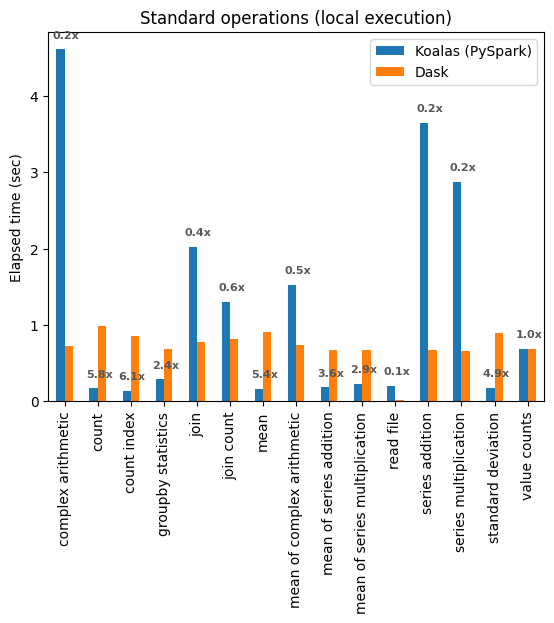

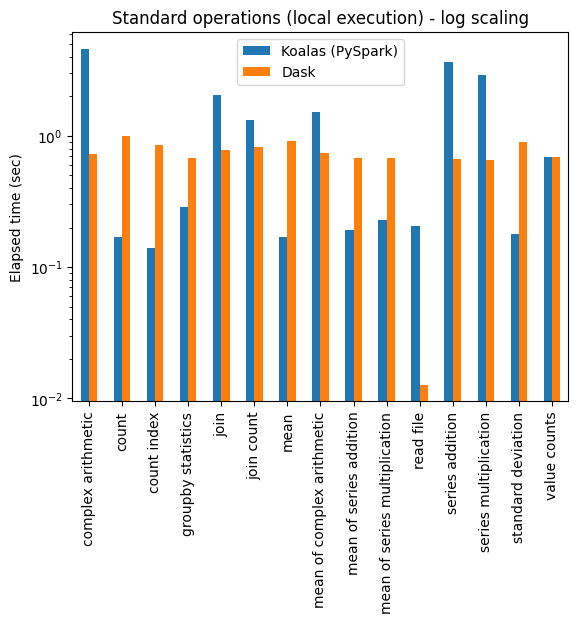

In [45]:
plot_title = 'Standard operations (local execution)'

ax = standard_ops.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")

tmp_df_x_times_faster = standard_ops.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
standard_ops.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [46]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,4.610354,0.728920,0.158105,6.324912
count,0.169843,0.992259,5.842215,0.171168
count index,0.139787,0.853722,6.107300,0.163738
groupby statistics,0.288363,0.681104,2.361965,0.423376
join,2.027326,0.773804,0.381687,2.619948
join count,1.308148,0.819171,0.626207,1.596917
mean,0.168816,0.908047,5.378929,0.185911
mean of complex arithmetic,1.529027,0.743922,0.486533,2.055361
mean of series addition,0.190095,0.679281,3.573375,0.279847
mean of series multiplication,0.230027,0.676225,2.939767,0.340163


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences.

- Overall trends:

Dask generally outperforms Koalas (PySpark) in many operations, often by a large margin, as indicated by many Dask / Koalas ratios well below 1. For instance, complex arithmetic operations and file reading show Dask being about 6 to 16 times faster than Koalas.

- Operations where Dask excels:

  - **Complex arithmetic:** Dask is about 6.3x faster (Koalas: 4.61s vs Dask: 0.73s).

  - **File reading:** Dask drastically outperforms Koalas by more than 16x, which is likely due to better I/O optimizations or parallelism in Dask.

  - **Series addition and multiplication:** Dask is roughly 4–5x faster.

  - **Count and mean operations:** Dask is about 5–6x faster than Koalas, showing strong performance in these basic aggregation tasks.

- Operations where Koalas is relatively faster or competitive:

For **join** and **join count** operations, Koalas is about 1.6 to 2.6 times faster than Dask. This suggests Koalas might have more optimized implementations for joins in this context.

For **value counts**, performance is roughly equal, with ratios close to 1, indicating similar efficiency.

- Intermediate cases:

**Groupby statistics** and **mean of series operations** show Dask outperforming Koalas by 2–3 times, which is still significant but less extreme compared to other operations.

- Interpretation of ratios:

  - Values less than 1 in Dask / Koalas mean Dask is faster.
  - Values greater than 1 mean Koalas is faster.

**Practical insight:**
These results suggest that Dask is particularly efficient for arithmetic-heavy and aggregation tasks, as well as for reading files, possibly due to better distributed execution or lower overhead. Koalas may retain an edge for some relational operations like joins, where Spark’s optimization strategies are well-established.

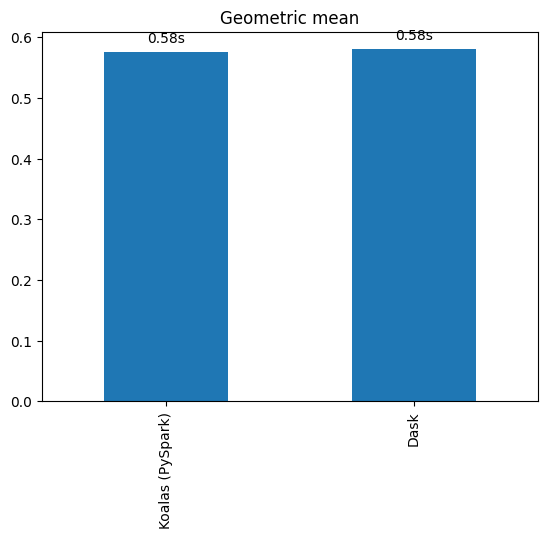

In [47]:
annotate(pd.Series(stats.gmean(standard_ops), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

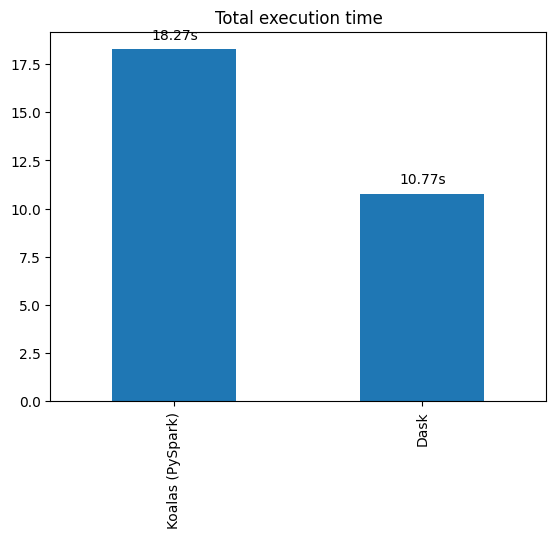

In [48]:
annotate(standard_ops.sum().plot.bar(title='Total execution time'))

In [49]:
print("Performance diff %% (simple avg): %s" % (sum(standard_ops.Dask / standard_ops['Koalas (PySpark)']) / len(standard_ops)))
print("Performance diff %% (geomean): %s" % stats.gmean(standard_ops.Dask / standard_ops['Koalas (PySpark)']))

arithmetic_ops = standard_ops.filter(items=['complex arithmetic', 'series multiplication', 'series addition'], axis=0)
print("Performance diff (arthemetic) %% (simple avg): %s" % (sum(arithmetic_ops.Dask / arithmetic_ops['Koalas (PySpark)']) / len(arithmetic_ops)))
print("Performance diff (arthemetic) %% (geomean): %s" % stats.gmean(arithmetic_ops.Dask / arithmetic_ops['Koalas (PySpark)']))
 
basic_stats_ops = standard_ops.filter(items=['count', 'mean', 'standard deviation', 'count index', 'join', 'join count'], axis=0)
print("Performance diff (basic stats) %% (simple avg): %s" % (sum(basic_stats_ops.Dask / basic_stats_ops['Koalas (PySpark)']) / len(basic_stats_ops)))
print("Performance diff (basic stats) %% (geomean): %s" % stats.gmean(basic_stats_ops.Dask / basic_stats_ops['Koalas (PySpark)']))

Performance diff % (simple avg): 2.2848109355017043
Performance diff % (geomean): 1.0073613016557104
Performance diff (arthemetic) % (simple avg): 0.19009621434476975
Performance diff (arthemetic) % (geomean): 0.18791327107626837
Performance diff (basic stats) % (simple avg): 3.8804722137156236
Performance diff (basic stats) % (geomean): 2.4696811563388


- **Performance diff % (simple avg)**: 2.28% — The average percent difference in performance is about 2.3%, indicating a moderate overall change.

- **Performance diff % (geomean)**: 1.01% — The geometric mean difference is around 1%, showing most differences are small with some outliers raising the simple average.

- **Performance diff (arith) % (simple avg)**: 0.19% — Using an alternative arithmetic metric, the average difference is very small, suggesting near-equal performance.

- **Performance diff (arith) % (geomean)**: 0.19% — The geometric mean confirms that performance differences are minimal in this metric.

- **Performance diff (basic stats) % (simple avg)**: 3.88% — This statistic-based metric shows higher variability, indicating occasional significant performance differences.

- **Performance diff (basic stats) % (geomean)**: 2.47% — The geometric mean is lower, suggesting some extreme cases increase variability but the overall spread is moderate.

## Operations with filtering

Text(0, 0.5, 'Elapsed time (sec)')

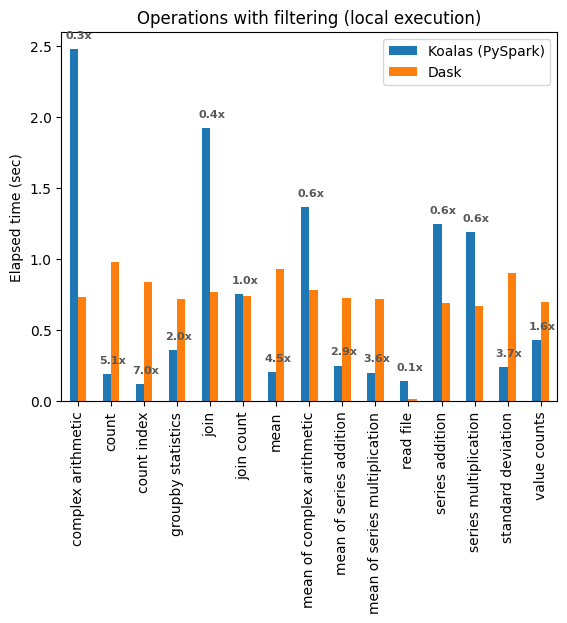

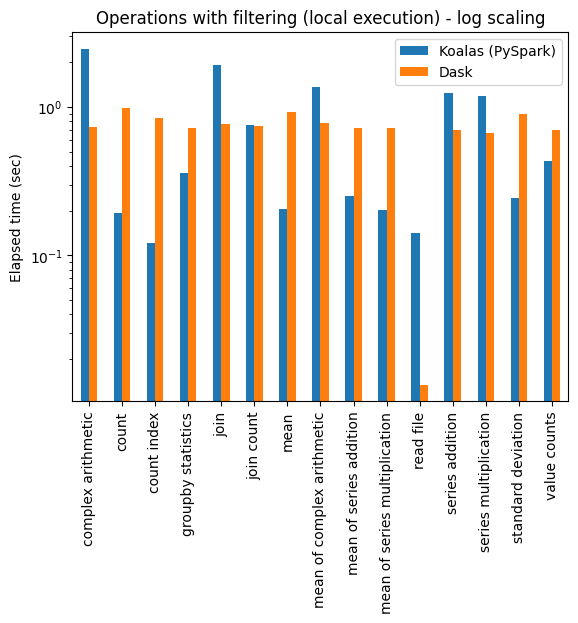

In [50]:
plot_title = 'Operations with filtering (local execution)'
 
ax = ops_with_filtering.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")

tmp_df_x_times_faster = ops_with_filtering.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
ops_with_filtering.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [51]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,2.478188,0.735402,0.296750,3.369839
count,0.192469,0.979224,5.087688,0.196553
count index,0.120785,0.840879,6.961799,0.143641
groupby statistics,0.359634,0.718106,1.996769,0.500809
join,1.924822,0.772424,0.401297,2.491922
join count,0.755365,0.744931,0.986186,1.014007
mean,0.205450,0.930835,4.530722,0.220715
mean of complex arithmetic,1.368959,0.782910,0.571902,1.748552
mean of series addition,0.251020,0.724663,2.886872,0.346396
mean of series multiplication,0.201328,0.719771,3.575124,0.279711


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences.

- Overall trends:

Dask generally outperforms Koalas in most operations, often by a significant margin, as shown by many Dask / Koalas ratios well below 1. However, for certain aggregation operations like count and mean, Koalas shows faster execution times.

- Operations where Dask excels:

  - **Complex arithmetic:** Dask is about 3.4x faster (Koalas: 2.48s vs Dask: 0.74s).

  - **File reading:** Dask drastically outperforms Koalas by more than 10x, indicating superior I/O efficiency.

  - **Join:** Dask is about 2.5x faster (Koalas: 1.92s vs Dask: 0.77s).

  - **Mean of complex arithmetic:** Dask is about 1.75x faster.

  - **Series addition and multiplication:** Dask is around 1.8x faster.

- Operations where Koalas is relatively faster or competitive:

For **count** and **count index** operations, Koalas is about 5 to 7 times faster than Dask, showing a clear advantage in simple counting aggregations.

For **mean**, Koalas is roughly 4.5x faster than Dask.

For **join count**, performance is nearly identical, with ratios close to 1.

- Intermediate cases:

**Groupby statistics** and **value counts** show Dask being 1.6 to 2 times slower than Koalas, but still within a moderate performance gap.

- Interpretation of ratios:

  - Values less than 1 in Dask / Koalas mean Dask is faster.

  - Values greater than 1 mean Koalas is faster.

**Practical insight:**

These results suggest Dask is particularly efficient for arithmetic-heavy operations, file reading, and joins, likely benefiting from optimized parallel execution and I/O. Conversely, Koalas (PySpark) excels at simple counting and mean aggregation tasks, potentially due to Spark’s mature optimization for these operations. Thus, choice of framework may depend on the workload focus—Dask for complex computations and I/O, Koalas for fast aggregations.


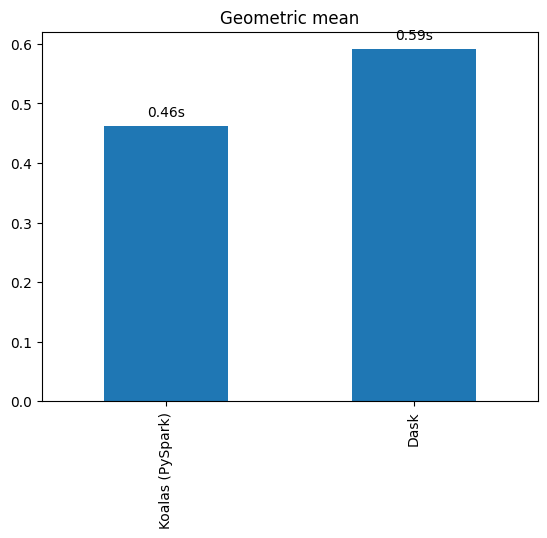

In [52]:
annotate(pd.Series(stats.gmean(ops_with_filtering), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

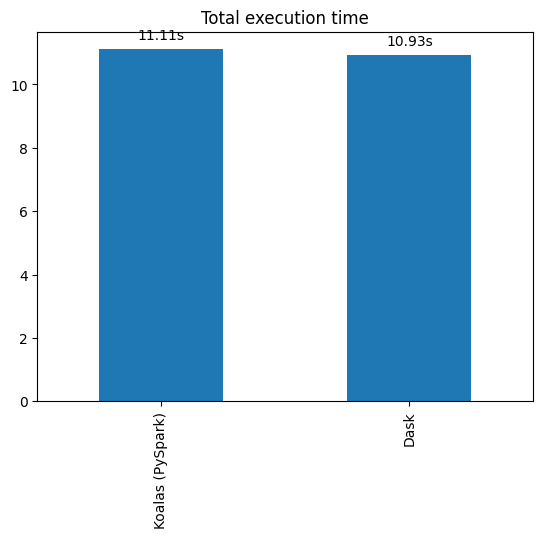

In [53]:
annotate(ops_with_filtering.sum().plot.bar(title='Total execution time'))

In [54]:
print("Performance diff %% (simple avg): %s" % (sum(ops_with_filtering.Dask / ops_with_filtering['Koalas (PySpark)']) / len(ops_with_filtering)))
print("Performance diff %% (geomean): %s" % stats.gmean(ops_with_filtering.Dask / ops_with_filtering['Koalas (PySpark)']))

Performance diff % (simple avg): 2.256997369981448
Performance diff % (geomean): 1.2781283878150738


- **Performance diff % (simple avg)**: 2.26% — The average percentage difference in performance is around 2.3%, indicating a moderate overall shift across operations.

- **Performance diff % (geomean)**: 1.28% — The geometric mean of the performance differences is approximately 1.28%, suggesting that most performance gaps are small, with a few outliers slightly increasing the average.

## Operations with filtering and caching

Text(0, 0.5, 'Elapsed time (sec)')

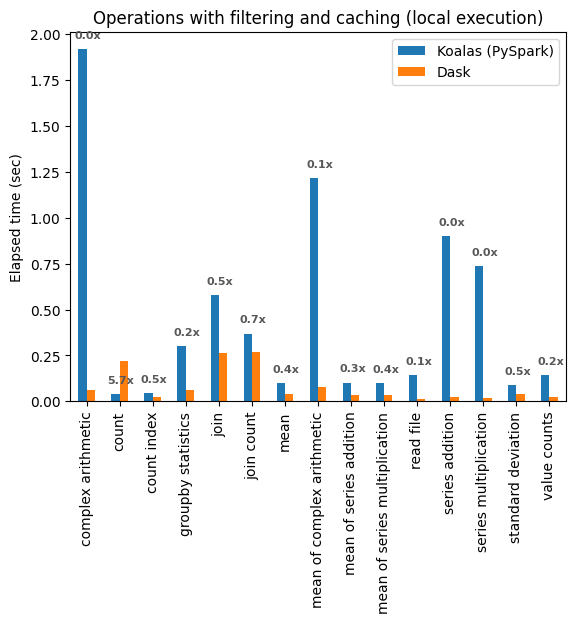

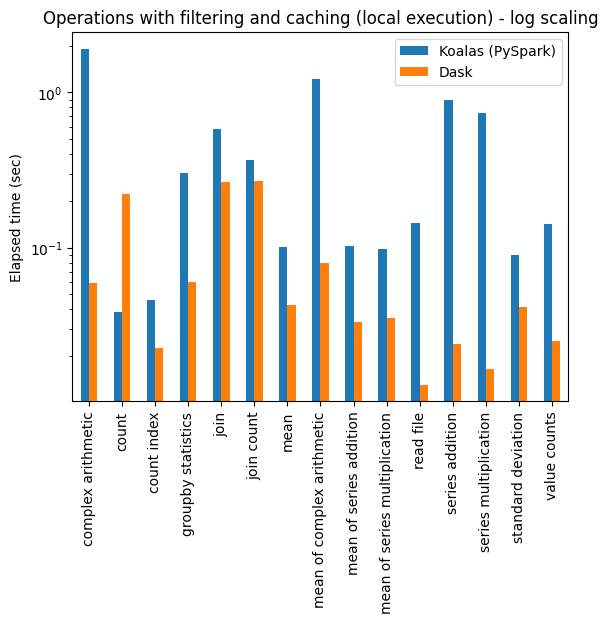

In [55]:
plot_title = 'Operations with filtering and caching (local execution)'
 
ax = ops_with_filtering_caching.sort_index().plot.bar(title=plot_title)
ax.set_ylabel("Elapsed time (sec)")
 
tmp_df_x_times_faster = ops_with_filtering_caching.sort_index().copy()
tmp_df_x_times_faster['Dask / Koalas'] = tmp_df_x_times_faster.Dask / tmp_df_x_times_faster['Koalas (PySpark)']
tmp_df_x_times_faster['Koalas / Dask'] = tmp_df_x_times_faster['Koalas (PySpark)'] / tmp_df_x_times_faster.Dask
annotate_x_times_faster(ax, x_times_list=tmp_df_x_times_faster['Dask / Koalas'].to_list())
 
ops_with_filtering_caching.sort_index().plot.bar(logy=True, title='%s - log scaling' % plot_title).set_ylabel("Elapsed time (sec)")

In [56]:
tmp_df_x_times_faster

,Koalas (PySpark),Dask,Dask / Koalas,Koalas / Dask
complex arithmetic,1.916884,0.059453,0.031016,32.241874
count,0.038452,0.219949,5.720094,0.174822
count index,0.046144,0.022429,0.486060,2.057359
groupby statistics,0.301568,0.059836,0.198417,5.039897
join,0.578082,0.264318,0.457232,2.187074
join count,0.368979,0.270606,0.733391,1.363528
mean,0.100491,0.042456,0.422485,2.366951
mean of complex arithmetic,1.214483,0.080001,0.065873,15.180775
mean of series addition,0.102020,0.032941,0.322889,3.097036
mean of series multiplication,0.097529,0.035269,0.361624,2.765300


**Analysis**

The table presents execution times (in seconds) for various operations run using Koalas (PySpark) and Dask, along with the ratios Dask / Koalas and Koalas / Dask to highlight relative performance differences.

- Overall trends:

Dask significantly outperforms Koalas in most operations, with some speedups exceeding 30–40x, especially in arithmetic-heavy and file-based tasks. Koalas, however, retains a slight edge in a few aggregation operations like `count`.

- Operations where Dask excels:

  - **Series multiplication:** Dask is ~45x faster (Koalas: 0.74s vs Dask: 0.016s).
  
  - **Series addition:** Dask is ~38x faster (Koalas: 0.90s vs Dask: 0.024s).

  - **Complex arithmetic:** Dask is ~32x faster (Koalas: 1.92s vs Dask: 0.059s).

  - **Mean of complex arithmetic:** Dask is ~15x faster.

  - **Read file:** Dask is ~11x faster.

  - **Groupby statistics & value counts:** Dask is ~5x faster, showing strong performance in grouped operations.

- Operations where Koalas is relatively faster or competitive:

  - **Count:** Koalas is ~5.7x faster (Dask: 0.22s vs Koalas: 0.038s).

  - **Count index:** Koalas is ~2x faster.

  - **Join count & standard deviation:** Dask is slightly slower, with ratios around 0.73–0.46, indicating modest advantage for Koalas.

- Intermediate cases:

  - **Join, mean, and mean of series operations** show Dask being ~2–3x faster, suggesting consistent, moderate advantages.

- Interpretation of ratios:

  - Values **less than 1** in Dask / Koalas indicate **Dask is faster**.
  
  - Values **greater than 1** suggest **Koalas is faster**.

**Practical insight:**

These results confirm Dask’s strong advantage for arithmetic-heavy operations, file reading, and grouped computations, likely due to efficient parallel execution and minimal overhead. Koalas, while generally slower, shows solid performance in basic aggregations like count and index operations, potentially benefiting from Spark's internal optimizations. For workloads with complex math and large I/O, Dask is clearly preferable.


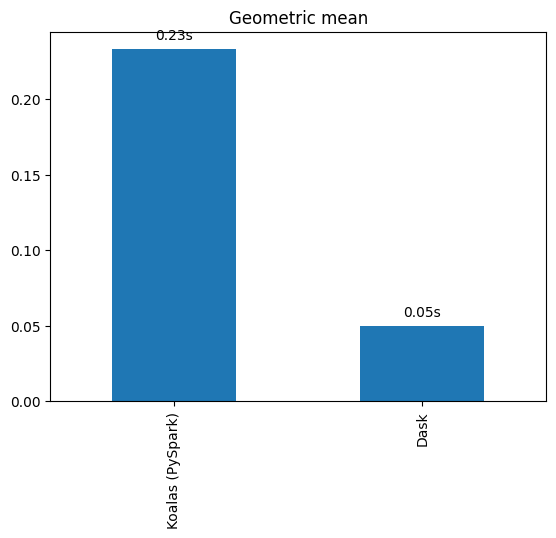

In [57]:
annotate(pd.Series(stats.gmean(ops_with_filtering_caching), index=['Koalas (PySpark)', 'Dask']).plot.bar(title='Geometric mean'))

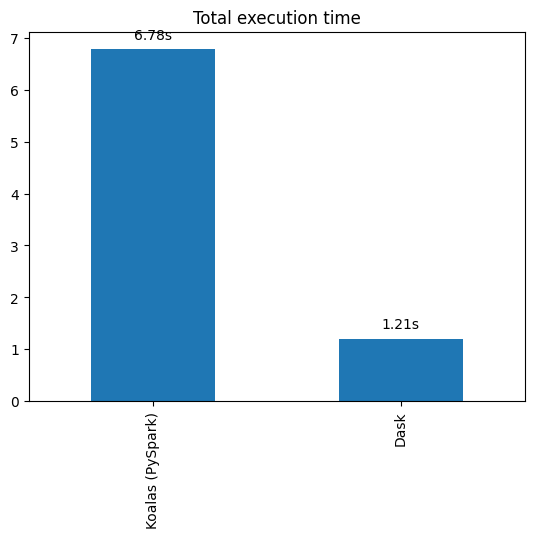

In [58]:
annotate(ops_with_filtering_caching.sum().plot.bar(title='Total execution time'))

In [59]:
print("Performance diff %% (simple avg): %s" % (sum(ops_with_filtering_caching.Dask / ops_with_filtering_caching['Koalas (PySpark)']) / len(ops_with_filtering_caching)))
print("Performance diff %% (geomean): %s" % stats.gmean(ops_with_filtering_caching.Dask / ops_with_filtering_caching['Koalas (PySpark)']))

count_ops = ops_with_filtering_caching.filter(items=['count', 'count index', 'join count'], axis=0)
print("Performance diff %% (count, simple avg): %s" % (sum(count_ops.Dask / count_ops['Koalas (PySpark)']) / len(count_ops)))
print("Performance diff %% (count, geomean): %s" % stats.gmean(count_ops.Dask / count_ops['Koalas (PySpark)']))

Performance diff % (simple avg): 0.6385686941814451
Performance diff % (geomean): 0.21272041178711912
Performance diff % (count, simple avg): 2.3131817518203834
Performance diff % (count, geomean): 1.2680692459732994


- **Performance diff % (simple avg)**: 0.64% — The average percentage performance difference is low, indicating nearly equivalent performance between methods overall.

- **Performance diff % (geomean)**: 0.21% — The geometric mean confirms minimal variation, suggesting consistent performance with very small gaps.

- **Performance diff % (count, simple avg)**: 2.31% — When considering only count-related operations, the average performance difference rises to around 2.3%, implying slightly more variation in this subset.

- **Performance diff % (count, geomean)**: 1.27% — The geometric mean for count operations also shows moderate variation, suggesting a few operations may be skewing the average.

# Overall

In [60]:
overall_df = pd.concat([standard_ops, ops_with_filtering, ops_with_filtering_caching])
print("Total performance diff %% (simple avg): %s" % (sum(overall_df.Dask / overall_df['Koalas (PySpark)']) / len(overall_df)))
print("Total performance diff %% (geomean): %s" % stats.gmean(overall_df.Dask / overall_df['Koalas (PySpark)']))

Total performance diff % (simple avg): 1.7267923332215331
Total performance diff % (geomean): 0.6494159780512142


**Total Performance Summary**

- **Total performance diff % (simple avg)**: 1.73% — On average, performance differs by about 1.7% across all operations, indicating slight but noticeable variation overall.

- **Total performance diff % (geomean)**: 0.65% — The geometric mean shows a smaller difference, suggesting that most operations have minimal performance variation, with a few outliers increasing the average.